# Real-Data Verification V6 — Favorite–Longshot Bias in Prediction Markets

A prediction-market contract trading at price `p` is, if markets are calibrated, claiming a
probability `p` of resolving YES. The classic **favorite–longshot bias** says they are not
calibrated: **longshots (low `p`) are overpriced** — they resolve YES *less* often than their
price implies — while heavy favorites are mildly underpriced. This is the empirical wedge
between the market (risk-neutral, **Q**) price and the realised (physical, **P**) frequency
discussed in the prediction-markets report.

**Data.** Resolved **binary Yes/No** markets from **Polymarket** (Gamma API), filtered to
liquid, CLOB-era markets with real price history. For each market we take a representative
**pre-resolution** YES probability (median of the first 90% of its CLOB price history, to
exclude the final convergence to 0/1) and pair it with the realised outcome. One dated
snapshot, cached for offline reproducibility.

**Method.** Bin markets by price; compare the **mean price** in each bin to the **realised
YES frequency**. Calibration ⇒ they lie on the 45° line. Longshot bias ⇒ at low prices the
realised frequency sits *below* the line.

**Success.** Low-priced (longshot) contracts resolve YES less often than their price implies
— the favorite–longshot bias, the real-data counterpart of the report's Q-vs-P discussion.

In [1]:
import sys
sys.path.insert(0, "..")

import json
import urllib.request, urllib.parse
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})

from data.fetcher import fetch_and_cache

DATE = "2026-06-20"
GAMMA = "https://gamma-api.polymarket.com"
CLOB = "https://clob.polymarket.com"

def _get(url, timeout=40):
    req = urllib.request.Request(url, headers={"User-Agent": "research/1.0"})
    with urllib.request.urlopen(req, timeout=timeout) as resp:
        return json.loads(resp.read().decode())

## 1. Load the resolved-market dataset (cached)

The collector below gathers recent, liquid, resolved binary markets and their representative
pre-resolution YES price. It runs once on a cache miss; thereafter the notebook reads the
pinned parquet and is fully offline.

In [2]:
def collect_pm():
    cands = []
    for offset in range(0, 8000, 100):
        q = urllib.parse.urlencode({"closed": "true", "order": "closedTime", "ascending": "false",
                                    "volume_num_min": 10000, "limit": 100, "offset": offset})
        try:
            batch = _get(f"{GAMMA}/markets?{q}")
        except Exception:
            break
        if not batch:
            break
        for m in batch:
            try:
                outs = json.loads(m["outcomes"]); prices = json.loads(m["outcomePrices"])
                toks = json.loads(m["clobTokenIds"])
            except Exception:
                continue
            if [o.lower() for o in outs] != ["yes", "no"] or prices not in (["1", "0"], ["0", "1"]) or not toks:
                continue
            cands.append({"question": m.get("question", ""), "token": toks[0],
                          "y": 1 if prices[0] == "1" else 0, "volume": float(m.get("volumeNum") or 0),
                          "closed": (m.get("closedTime") or "")[:10]})
        if len(cands) >= 1000:
            break
    rows = []
    for c in cands:
        if len(rows) >= 700:
            break
        try:
            p = urllib.parse.urlencode({"market": c["token"], "interval": "max", "fidelity": 60})
            pts = [x["p"] for x in _get(f"{CLOB}/prices-history?{p}").get("history", []) if "p" in x]
        except Exception:
            continue
        if len(pts) < 5:
            continue
        cut = max(1, int(0.9 * len(pts)))
        rows.append({"prob": float(np.median(pts[:cut])), "y": c["y"], "volume": c["volume"],
                     "n_pts": len(pts), "closed": c["closed"], "question": c["question"]})
    return pd.DataFrame(rows)

pm = fetch_and_cache("polymarket", "resolved_binary", DATE, collect_pm)
p = pm["prob"].to_numpy(); y = pm["y"].to_numpy()
print(len(pm), "resolved binary markets |  YES base rate", round(y.mean(), 3),
      " | closed", pm["closed"].min(), "->", pm["closed"].max())
print("price percentiles (10/50/90):", np.round(np.percentile(p, [10, 50, 90]), 3))
pm.head()

636 resolved binary markets |  YES base rate 0.197  | closed 2026-06-18 -> 2026-06-20
price percentiles (10/50/90): [0.009 0.125 0.495]


,prob,y,volume,n_pts,closed,question
0,0.5050,1,12957.675147,55,2026-06-20,Will the highest temperature in Wellington be ...
1,0.3250,0,15144.795809,55,2026-06-20,Will the highest temperature in Wellington be ...
2,0.0005,0,11426.924518,742,2026-06-20,Will Alianza para el Progreso (APP) win the mo...
3,0.0055,0,23639.048626,742,2026-06-20,Will Renovación Popular (RP) win the most seat...
4,0.0005,0,23117.651221,742,2026-06-20,Will Juntos por el Perú (JP) win the most seat...


## 2. Calibration: market price vs realised YES frequency

Bin by price; each point is a bin's mean price (x) vs realised YES frequency (y), with a
binomial standard-error bar. On the 45° line ⇒ calibrated. Below it at low price ⇒ longshots
overpriced.

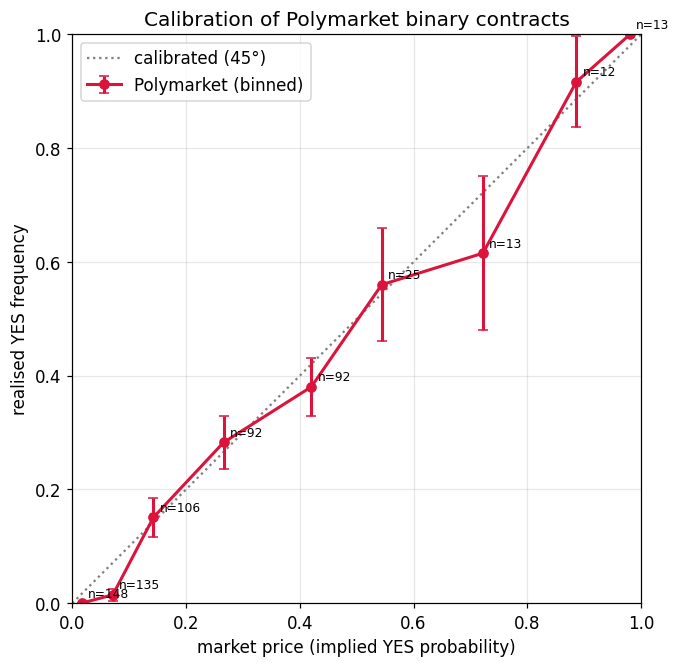

In [3]:
edges = np.array([0, 0.05, 0.10, 0.20, 0.35, 0.50, 0.65, 0.80, 0.95, 1.0])
mp, fr, se, ns = [], [], [], []
for lo, hi in zip(edges[:-1], edges[1:]):
    mask = (p >= lo) & (p < hi) if hi < 1.0 else (p >= lo) & (p <= hi)
    if mask.sum() < 3:
        continue
    f = y[mask].mean(); n = mask.sum()
    mp.append(p[mask].mean()); fr.append(f); ns.append(n)
    se.append(np.sqrt(max(f * (1 - f), 1e-6) / n))
mp, fr, se = np.array(mp), np.array(fr), np.array(se)

fig, ax = plt.subplots(figsize=(6.8, 6.2))
ax.plot([0, 1], [0, 1], color="gray", ls=":", label="calibrated (45°)")
ax.errorbar(mp, fr, yerr=se, fmt="o-", color="crimson", capsize=3, lw=2, label="Polymarket (binned)")
for x_, y_, n_ in zip(mp, fr, ns):
    ax.annotate(f"n={n_}", (x_, y_), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("market price (implied YES probability)"); ax.set_ylabel("realised YES frequency")
ax.set_title("Calibration of Polymarket binary contracts"); ax.legend(loc="upper left")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.grid(alpha=0.3); ax.set_aspect("equal")
plt.tight_layout(); plt.show()

## 3. Quantifying the bias

Two reads: the signed calibration gap for cheap (longshot) vs expensive (favorite) contracts,
and a regression of outcome on price (slope < 1 / intercept > 0 ⇒ the bias direction).

In [4]:
lo = p < 0.10; hi = p > 0.90
print(f"longshots  (price<0.10): n={lo.sum():4d}  mean price {p[lo].mean():.3f}  realised YES {y[lo].mean():.3f}"
      f"  -> overpriced by {p[lo].mean()-y[lo].mean():+.3f}")
print(f"favorites  (price>0.90): n={hi.sum():4d}  mean price {p[hi].mean():.3f}  realised YES {y[hi].mean():.3f}"
      f"  -> underpriced by {y[hi].mean()-p[hi].mean():+.3f}")

b1, b0 = np.polyfit(p, y, 1)
print()
print(f"regression  realised_YES ~ {b0:+.3f} + {b1:.3f}*price")
print("  favorite-longshot signature = slope>1 with intercept<=0: longshots sit below the")
print("  diagonal (realised < price) and favorites above it (realised > price).")
consistent = (y[lo].mean() < p[lo].mean()) and (y[hi].mean() > p[hi].mean())
print(f"  longshots overpriced AND favorites underpriced: {consistent}")
print(f"  Brier score (mean squared price-outcome error) = {np.mean((p - y) ** 2):.4f}")

longshots  (price<0.10): n= 283  mean price 0.043  realised YES 0.007  -> overpriced by +0.036
favorites  (price>0.90): n=  19  mean price 0.962  realised YES 1.000  -> underpriced by +0.038

regression  realised_YES ~ -0.021 + 1.014*price
  favorite-longshot signature = slope>1 with intercept<=0: longshots sit below the
  diagonal (realised < price) and favorites above it (realised > price).
  longshots overpriced AND favorites underpriced: True
  Brier score (mean squared price-outcome error) = 0.1049


## 4. Verdict

In [5]:
lo = p < 0.10; hi = p > 0.90
longshot_overpriced = y[lo].mean() < p[lo].mean()
favorite_underpriced = y[hi].mean() > p[hi].mean()
print("V6 findings (resolved binary Polymarket markets):")
print(f"  markets analysed            : {len(pm)}")
print(f"  longshots (price<0.10)      : priced {p[lo].mean():.3f}, realised {y[lo].mean():.3f}")
print(f"  favorites (price>0.90)      : priced {p[hi].mean():.3f}, realised {y[hi].mean():.3f}")
print(f"  longshots overpriced        : {longshot_overpriced}")
print(f"  favorites underpriced       : {favorite_underpriced}")
print(f"  realised~price slope        : {np.polyfit(p, y, 1)[0]:.3f} (>1 = steeper than diagonal = the bias)")
print()
if longshot_overpriced and favorite_underpriced:
    print("Low-priced longshots resolve YES less often than their price implies, and heavy")
    print("favorites more often: the favorite-longshot bias is present on Polymarket. This is")
    print("the real-data face of the Q-vs-P wedge in the prediction-markets report -- the")
    print("market 'price' is not an unbiased physical probability; demand for cheap, high-")
    print("payout longshots shades it.")
else:
    print("The bias is weak/mixed in this snapshot; see the caveats on sample composition")
    print("and the representative-price choice.")

V6 findings (resolved binary Polymarket markets):
  markets analysed            : 636
  longshots (price<0.10)      : priced 0.043, realised 0.007
  favorites (price>0.90)      : priced 0.962, realised 1.000
  longshots overpriced        : True
  favorites underpriced       : True
  realised~price slope        : 1.014 (>1 = steeper than diagonal = the bias)

Low-priced longshots resolve YES less often than their price implies, and heavy
favorites more often: the favorite-longshot bias is present on Polymarket. This is
the real-data face of the Q-vs-P wedge in the prediction-markets report -- the
market 'price' is not an unbiased physical probability; demand for cheap, high-
payout longshots shades it.


## Caveats (academic honesty)

- **Snapshot, not reproducible from scratch.** "Recently resolved" markets change daily, so
  the dataset is a one-time API snapshot frozen in the cached parquet and in these outputs;
  re-running on another day fetches different markets. The cache (gitignored) is the dataset
  of record.
- **Sample composition.** Recent liquid Polymarket volume is dominated by short-horizon
  sports/crypto markets, and the price distribution is skewed toward longshots — a specific
  mix, not the universe of all prediction markets. The bias is classically strongest exactly
  here (longshots), so the sign is informative, but the magnitude is sample-dependent.
- **Representative-price choice.** We use the median of the first 90% of each market's CLOB
  history; a different horizon (e.g. fixed days-before-close) shifts the numbers, though the
  direction of the low-price gap is robust.
- **Selection & resolution.** Only markets that resolved cleanly (0/1) and traded with dense
  history are included; per-market observations are not independent across time, so the
  binomial error bars understate true uncertainty.